## 2. The Architecture: Attention and Wavelets
Standard Physics-Informed Neural Networks (PINNs) suffer from **Spectral Bias**—they naturally prefer learning low-frequency, smooth functions. The HH equations, however, are dominated by high-frequency, violent voltage spikes. If a standard MLP tries to learn this, it will either smooth out the spike or oscillate uncontrollably. 

We solve this using a two-pronged architectural approach:

### A. Global Temporal Awareness (Self-Attention)
The Transformer's Self-Attention mechanism computes how every single time point relates to every other time point in the sequence:
$$ \text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V $$
This allows the network to instantly correlate the slow buildup of the gating variables at $t=10$ms with the explosive voltage spike at $t=35$ms, entirely bypassing the need for an ODE solver.

### B. The Anti-Stiffness Weapon (Mexican Hat Wavelet)
To defeat Spectral Bias, we replace standard global activations (like $\tanh$) inside the Feed-Forward block with the **Mexican Hat Wavelet**:
$$ \psi(x) = (1 - x^2) \exp\left(-\frac{x^2}{2}\right) $$
Unlike $\tanh$, which affects the output everywhere, a wavelet is localized. It stays near zero during the flat resting potential, and sharply "fires" only when the HH dynamics demand an action potential. The network learns to stretch and shift these wavelets to perfectly capture high-frequency stiff dynamics without corrupting the smooth areas.

## 3. The Seq2Seq Physics Loss (Finite Differences)
Because we have eliminated the ODE solver, we can no longer evaluate the physics at a single point in time and step forward. We must enforce the Hodgkin-Huxley physics directly across the entire predicted sequence at once.

### The Physics Residual
We need to know the predicted temporal derivative ($du/dt$) of our sequence. Since doing continuous auto-differentiation through complex Attention layers is computationally brutal, we use **Central Finite Differences** across our discrete sequence $U_{pred}$:
$$ \frac{d u_i}{dt} \approx \frac{u_{i+1} - u_{i-1}}{2\Delta t} $$

We pass our interior sequence points through the exact HH physical equations—let's call that mathematical operator $\mathcal{F}(u)$—and penalize any difference between our sequence's actual derivative and the theoretical derivative:
$$ \mathcal{L}_{phys} = \frac{1}{N} \sum_{i=2}^{N-1} \left\| \frac{u_{i+1} - u_{i-1}}{2\Delta t} - \mathcal{F}(u_i) \right\|^2 $$

*Note: Just like in the PI-NODE-SR framework, we still divide this residual by our Scale Factors ($s_j$) to ensure the massive voltage gradients do not drown out the tiny gating gradients!*

### `IMPORTING  All the important Julia Library`

In [5]:
# using  Flux,SciMLSensitivity, Optimization, OptimizationOptimisers, ComponentArrays, Zygote 
using Plots
using Flux                  # Neural network framework
using NNlib                 # Activation functions, softmax, etc.
using LinearAlgebra         # Matrix operations
using Statistics            # Mean, std
using Random                  # Random initialization
using Flux          

## Phase 1: Synthetic Data Enviourment Set Up
----

In [7]:

using CSV, DataFrames
 
file_path = raw"C:\NeuroPinnsFormmer-attention-that-neurons-needs\Synthetic_Data\HH_ground_truth_synthetic_data.csv"


HH_data = CSV.read(file_path, DataFrame)
first(HH_data,5)


Row,t,V,m,h,n
,Float64,Float64,Float64,Float64,Float64
1,0.0,-65.0,0.0529,0.5961,0.3177
2,0.01,-65.0,0.0529013,0.5961,0.3177
3,0.02,-65.0001,0.0529026,0.5961,0.3177
4,0.03,-65.0001,0.0529038,0.5961,0.3177
5,0.04,-65.0001,0.052905,0.5961,0.3177


In [8]:
println(describe(HH_data))
println(size(HH_data))


5×7 DataFrame
 Row │ variable  mean        min          median       max        nmissing  eltype   
     │ Symbol    Float64     Float64      Float64      Float64    Int64     DataType 
─────┼───────────────────────────────────────────────────────────────────────────────
   1 │ t          15.0         0.0         15.0        30.0              0  Float64
   2 │ V         -55.8323    -75.0786     -64.7892     40.2669           0  Float64
   3 │ m           0.193508    0.0160484    0.0553091   0.99417          0  Float64
   4 │ h           0.360832    0.0693089    0.408959    0.596112         0  Float64
   5 │ n           0.491562    0.317688     0.437201    0.770771         0  Float64
(3001, 5)


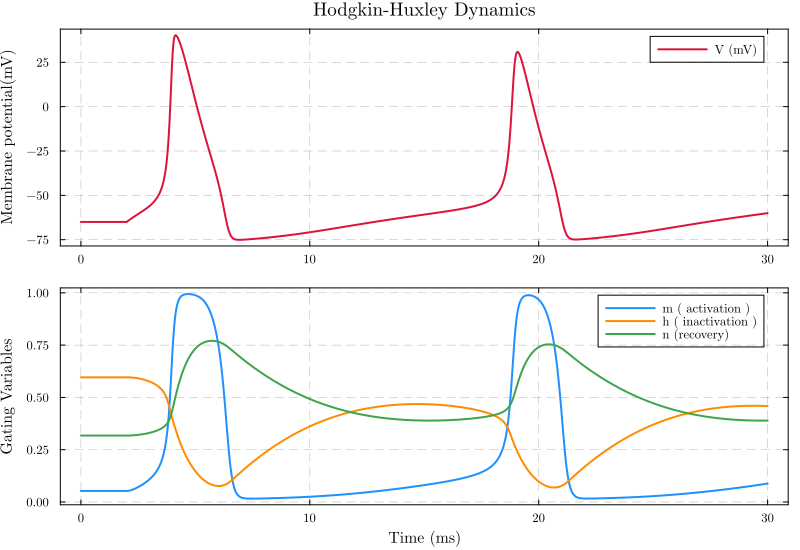

In [9]:
using Plots

# 1. Define a sleek, modern color palette
color_V = :crimson
color_m = :dodgerblue
color_h = :darkorange
color_n = :forestgreen


# 2. Configure global default aesthetics for premium look
default(
    fontfamily = "Computer Modern", # Or "Helvetica" / "sans-serif"
    titlefontsize = 12,
    guidefontsize = 10,
    tickfontsize = 8,
    legendfontsize = 8,
    grid = true,
    gridalpha = 0.15,
    gridstyle = :dash,
    frame = :box,
    lw = 2.0  # Line width
)

# membrane potential (V) over time (t)

p1=plot(HH_data.t,HH_data.V,color=color_V,label = "V (mV)",ylabel = "Membrane potential(mV)",title = "Hodgkin-Huxley Dynamics",
    legendbackgroundcolor = :transparent ,legend = :topright
)
# Creating subplots for gating variable (m,h,n) over time (t)

p2=plot(HH_data.t,HH_data.m,color=color_m,
label = "m ( activation )",
xlabel = "Time (ms)",
ylabel = "Gating Variables",legendbackgroundcolor = :transparent ,
legend = :topright)

plot!(HH_data.t,HH_data.h,
color=color_h,
label = "h ( inactivation )"
)
plot!(HH_data.t,HH_data.n
,label = "n (recovery)")

# now  combined them into a stacked layout sharing the X-axis

final_plot = plot(p1,p2, 
layout = grid(2,1,heights = [0.5,0.5])
,link = :x,
size = (800,550),
dpi = 100)
display(final_plot)

### Mini-Batch Data Transformation
----

In [10]:
# downgrade the data form float64 to float32 for better neural network learning 
t_raw = Float32.(HH_data.t)
# converting data form ( 1d ---> 3d) [ Features , Sequence , TotalData]
t_tensor = reshape(t_raw, 1, 1, length(t_raw)) # --> deck of 3001 card arranged one after another backward


1×1×3001 Array{Float32, 3}:
[:, :, 1] =
 0.0

[:, :, 2] =
 0.01

[:, :, 3] =
 0.02

;;; … 

[:, :, 2999] =
 29.98

[:, :, 3000] =
 29.99

[:, :, 3001] =
 30.0

In [11]:
println(size(t_tensor))
batch_size = 64
data_loader = Flux.DataLoader(t_tensor,batchsize=batch_size,shuffle=true )

(1, 1, 3001)


47-element DataLoader(::Array{Float32, 3}, shuffle=true, batchsize=64)
  with first element:
  1×1×64 Array{Float32, 3}

--------

In [63]:
x=first(data_loader)
t_batch = x[:, :, 1:64]
k=10


10

## Phase 2 : Hierarchical Timescale PINNsFormer Pipeline
    Phase 2 focuses on building the neural network architecture. By splitting the workflow into parallel temporal tracks, you resolve the extreme stiffness mismatch between ultra-fast activation dynamics V,m  and slow channel recovery (h, n).

### Step 1: Generation ( X_fine and Y_Coarse)
---

In [64]:
function generate_tranjectories(t_batch,k; dt_fine=0.05f0, dt_coarse=0.5f0)

    steps = reshape(0:(k-1),1,k,1)
    T_fine = t_batch .+ ( steps .* dt_fine)
    T_coarse = t_batch .+ ( steps .* dt_coarse)

    return T_fine,T_coarse

    
end

generate_tranjectories (generic function with 1 method)

In [65]:
T_Fine , T_coarse = generate_tranjectories(t_batch,k)

(Float32[8.47 8.52 … 8.87 8.92;;; 5.35 5.4 … 5.75 5.7999997;;; 20.79 20.84 … 21.19 21.240002;;; … ;;; 7.01 7.0600004 … 7.4100003 7.46;;; 17.27 17.32 … 17.67 17.720001;;; 15.25 15.3 … 15.65 15.7], Float32[8.47 8.97 … 12.47 12.97;;; 5.35 5.85 … 9.35 9.85;;; 20.79 21.29 … 24.79 25.29;;; … ;;; 7.01 7.51 … 11.01 11.51;;; 17.27 17.77 … 21.27 21.77;;; 15.25 15.75 … 19.25 19.75])

In [66]:
size(T_Fine)

(1, 10, 64)

----

## Step : 2 Hidden projection and positional encoding 

### 1. Feature Projection Pipeline
The raw coordinate input is linearly projected into the hidden feature space using weights and biases:
$$X = W_{\text{in}} \cdot T + b$$

### 2. Sinusoidal Positional Encoding (PE)
For a sequence step index $j$ (where $1 \le j \le k$) and a channel index $i$ tracking the hidden dimensions:

$$\text{PE}(2i, j) = \sin\left(\frac{j - 1}{10000^{\frac{2i}{d_{\text{model}}}}}\right)$$

$$\text{PE}(2i+1, j) = \cos\left(\frac{j - 1}{10000^{\frac{2i}{d_{\text{model}}}}}\right)$$


In [67]:
const d_model  = 32 # hidden feature size
fine_row = Flux.Dense(1 => d_model)
coarse_row = Flux.Dense(1 => d_model)

# projection form 1 Channel to d_model Channel    |  shape[ d_model X K X 64 ]

X_fine_row = fine_row(T_Fine)
X_coarse_row = coarse_row(T_coarse)
println(size(X_fine_row))
println(size(X_coarse_row))

(32, 10, 64)
(32, 10, 64)


In [68]:
# pre compute the positional encoding of shape [d_model,k,1]
pe = zeros(Float32,d_model,k)
for j in 1:k
    for i in 0:(div(d_model,2)-1)
        denom = 10000.0f0 ^ ( 2f0 * i / d_model)
        pe[2i+1,j] = sin((j-1)/denom)
        pe[2i+2,j] = sin((j-1)/denom)
    end
end

pe_broadcast = reshape(pe,d_model,k,1)

X_coarse = X_coarse_row .+pe_broadcast
X_fine  = X_fine_row .+pe_broadcast



32×10×64 Array{Float32, 3}:
[:, :, 1] =
 -3.16922    -2.34646    -2.29734    …  -2.6432    -2.32953   -2.92548
  2.14309     2.99721     3.07769        2.88863    3.23365    2.66906
  0.394895    0.930395    1.30169       -0.302508  -0.563717  -0.523948
  2.74173     3.29109     3.67623        2.14131    1.89395    1.94758
  3.58171     3.91384     4.21512        4.53013    4.32517    4.06326
 -2.89021    -2.59629    -2.33321    …  -2.20922   -2.45239   -2.75251
  1.59483     1.78113     1.96186        2.60806    2.65919    2.67912
  2.21575     2.40573     2.59012        3.25464    3.30944    3.33303
 -3.17883    -3.09776    -3.01769       -2.66597   -2.61159   -2.56439
 -0.124528   -0.0254298   0.072671       0.514544   0.586947   0.652183
 -0.0775168  -0.0217699   0.0337993  …   0.302832   0.353674   0.403141
  0.335879    0.394066    0.452076       0.73331    0.786592   0.8385
 -1.15613    -1.13134    -1.10658       -0.98435   -0.960438  -0.936777
  ⋮                               

---

## Step 4: Learnable Wavelet Activation Layer
$$\text{Wavelet}(Z) = \omega_1 \odot \sin(Z) + \omega_2 \odot \cos(Z)$$

In [69]:
# defing Custom WaveletActivation struct 
struct WaveletActivation
w1::AbstractVector
w2::AbstractVector
end

# act's like a constructor to initialize the variable
WaveletActivation(d_model::Int) = WaveletActivation(ones(Float32,d_model),ones(Float32,d_model))
@functor WaveletActivation

function (w::WaveletActivation)(x)
    return ( w.w1 .* sin.(x)) .+ (w.w2 .* cos.(x))
end



In [70]:
wavelet_layer = WaveletActivation(d_model)

WaveletActivation(Float32[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0  …  1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], Float32[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0  …  1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0])

In [71]:
Z_fine = wavelet_layer(X_fine)
Z_coarse = wavelet_layer(X_coarse)

32×10×64 Array{Float32, 3}:
[:, :, 1] =
 -1.1997    -1.25286   -1.03567   …  -0.112531   0.617164   0.103475
  0.58116    1.33918    1.35885       1.13444    1.33843    0.848332
 -0.754255  -1.34988   -1.37419      -1.23016   -1.16148   -1.30401
 -0.588222  -1.27694   -1.4086       -1.0774    -0.981452  -1.16566
 -0.707073  -1.19349   -1.40469      -0.830448  -0.893332  -1.01132
 -1.18673   -1.28123   -1.33789   …  -0.780767  -0.261142   0.377728
 -0.951832  -0.857412  -0.763168     -0.577468  -0.639042  -0.737131
 -1.33932   -1.31123   -1.2822       -1.28211   -1.32476   -1.37084
  0.521409   0.619412   0.712643      1.06555    1.10987    1.14561
 -1.3917    -1.37747   -1.35942      -1.18146   -1.1186    -1.04237
 -0.86934   -1.10462   -1.27939   …  -1.06137   -0.820955  -0.539302
 -0.744393  -0.996935  -1.19773      -1.19081   -0.99249   -0.746626
  1.06307    1.09547    1.12648       1.25853    1.28008    1.29997
  ⋮                               ⋱                        
  0.693205

In [72]:
size(Z_fine)

(32, 10, 64)

## Step 4 : Trannsformmer Encoder Block

$$A = \text{softmax}\left(\frac{Q K^T}{\sqrt{d_k}}\right)$$
$$H = A V$$

In [85]:
struct TransformerBlock
    mha::Flux.MultiHeadAttention
    norm1::Flux.LayerNorm
    ffn::Flux.Chain
    norm2::Flux.LayerNorm
end

Flux.@layer TransformerBlock
function TransformerBlock(d_model::Int, n_heads::Int)
    return TransformerBlock(
        # Pass d_model directly as a single integer argument
        Flux.MultiHeadAttention(d_model, nheads = n_heads),
        Flux.LayerNorm(d_model),
        # FFN incorporates our modern custom learnable Wavelet block
        Flux.Chain(Flux.Dense(d_model => d_model), WaveletActivation(d_model)),
        Flux.LayerNorm(d_model)
    )
end



TransformerBlock

In [86]:
function (t::TransformerBlock)(x)
    # intput --> (32, 10, 64)
    
    # 1.self-attention processing
    attn_out,_ = t.mha(x,x,x)  # Maps Q,K,V internally
    x = t.norm1(x.+attn_out)

    # postion wise feed forward
    ffn_out = t.ffn(x)
    x=t.norm2(x.+ ffn_out)

    return x
    
end

In [87]:
# Setup hyperparameters matching your layout
# d_model = 32
sequence_length = 10
n_heads = 4

# Initialize parallel encoder paths
fine_encoder = TransformerBlock(d_model, n_heads)
coarse_encoder = TransformerBlock(d_model, n_heads)

# Mock inputs from Step 3 [Shape: 32 × 10 × 64]
Z_fine = rand(Float32, d_model, sequence_length, 64)
Z_coarse = rand(Float32, d_model, sequence_length, 64)

32×10×64 Array{Float32, 3}:
[:, :, 1] =
 0.545711    0.434205    0.786428   …  0.464813   0.907557  0.785774
 0.979744    0.105728    0.382324      0.12896    0.617971  0.518171
 0.00324482  0.00724274  0.732291      0.128256   0.418195  0.745807
 0.992995    0.6281      0.746637      0.986548   0.883028  0.252628
 0.257925    0.674971    0.0498189     0.239832   0.162394  0.821212
 0.0310919   0.654128    0.147699   …  0.616142   0.969831  0.333637
 0.32411     0.120361    0.529648      0.457555   0.738643  0.818492
 0.39944     0.516424    0.861627      0.503021   0.194157  0.671638
 0.733597    0.726997    0.066966      0.169654   0.914972  0.106688
 0.626505    0.0677988   0.671471      0.975216   0.849788  0.508152
 0.137981    0.00670898  0.636733   …  0.011292   0.664219  0.783599
 0.147805    0.151199    0.772599      0.336475   0.78854   0.976816
 0.723227    0.452039    0.585013      0.436288   0.962535  0.706625
 ⋮                                  ⋱                       
 0